<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/RFSF_O3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import zipfile
import io

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
headers = {"User-Agent": "Mozilla/5.0"}

# Download shapefile zip
response = requests.get(url, headers=headers)
response.raise_for_status()

# Extract to current directory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall(".")

print(" Downloaded and extracted Natural Earth shapefile.")


 Downloaded and extracted Natural Earth shapefile.


In [8]:
import geopandas as gpd
import numpy as np
import rasterio.features
import xarray as xr
from affine import Affine

# === Load your NetCDF grid ===
ds = xr.open_dataset("BaseCase_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc")
lon = ds["lon"].values
lat = ds["lat"].values
ds.close()

lon2d, lat2d = np.meshgrid(lon, lat)

# === Define transform
res_lon = lon[1] - lon[0]
res_lat = lat[1] - lat[0]
transform = Affine.translation(lon[0] - res_lon / 2, lat[0] - res_lat / 2) * Affine.scale(res_lon, res_lat)

# === Load shapefile
gdf = gpd.read_file("ne_110m_admin_0_countries.shp").to_crs("EPSG:4326")

# === Create mapping from ISO_A3 to unique integer code
iso_codes = gdf["ISO_A3"].unique()
iso_to_int = {iso: i for i, iso in enumerate(iso_codes)}
int_to_iso = {v: k for k, v in iso_to_int.items()}  # Save for later

# === Rasterize using integer codes
shapes = ((geom, iso_to_int[iso]) for geom, iso in zip(gdf.geometry, gdf["ISO_A3"]))
country_mask_int = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=lon2d.shape,
    transform=transform,
    fill=-1,
    dtype="int16"
)

# === Save outputs
np.save("country_mask_int.npy", country_mask_int)
np.save("int_to_iso.npy", int_to_iso)

print(" Saved: country_mask_int.npy and int_to_iso.npy")


 Saved: country_mask_int.npy and int_to_iso.npy


# Additive

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


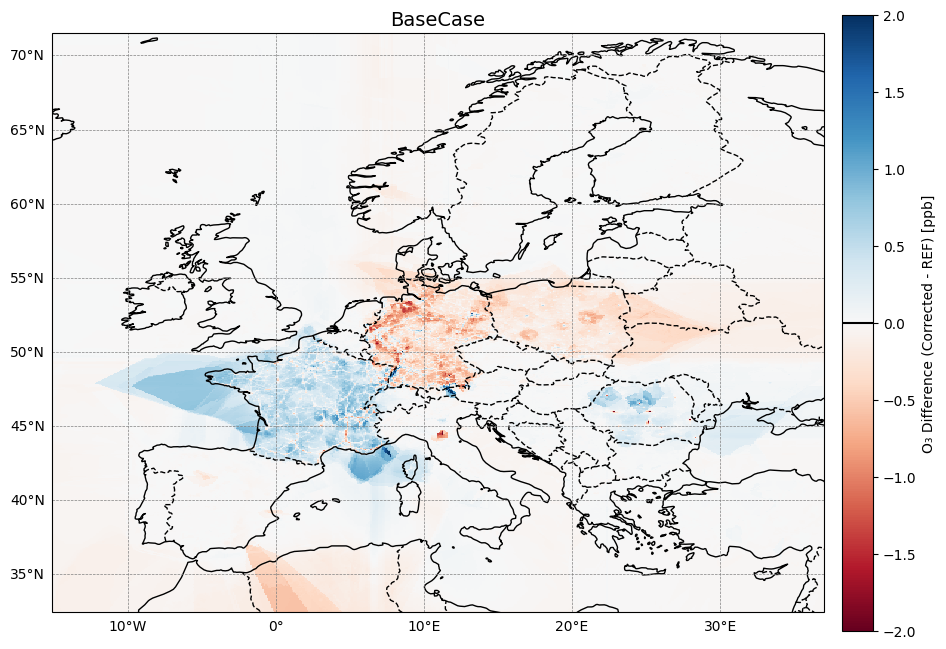

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === File Paths ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"  # UoA Corrected
file_B = "BaseCase_REF_O3_YEARLY.nc"  # Reference

# === Open NetCDFs ===
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract O₃ Fields ===
# Both will now have shape (lat, lon)
o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values

# === Compute Difference (Corrected - Reference) ===
o3_diff = o3_A - o3_B

# === Extract Coordinates (1D) and Meshgrid (2D) ===
lon = ds_A["lon"].values
lat = ds_A["lat"].values
lon2d, lat2d = np.meshgrid(lon, lat)  # Shape matches (lat, lon)

# === Define Colorbar Limits ===
vmin, vmax = -2, 2  # Adjust if needed

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon2d, lat2d, o3_diff, transform=ccrs.PlateCarree(),
                   cmap="RdBu", vmin=vmin, vmax=vmax, shading='nearest')

# === Colorbar ===
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("O₃ Difference (Corrected - REF) [ppb]")
cbar.ax.hlines(0, *cbar.ax.get_xlim(), colors='black', linewidth=1.5)

# === Map Features ===
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# === Gridlines ===
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# === Title and Labels ===
ax.set_title("BaseCase", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()


R² (Corrected vs Reference): 0.9989


/tmp/ipython-input-13-177157571.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


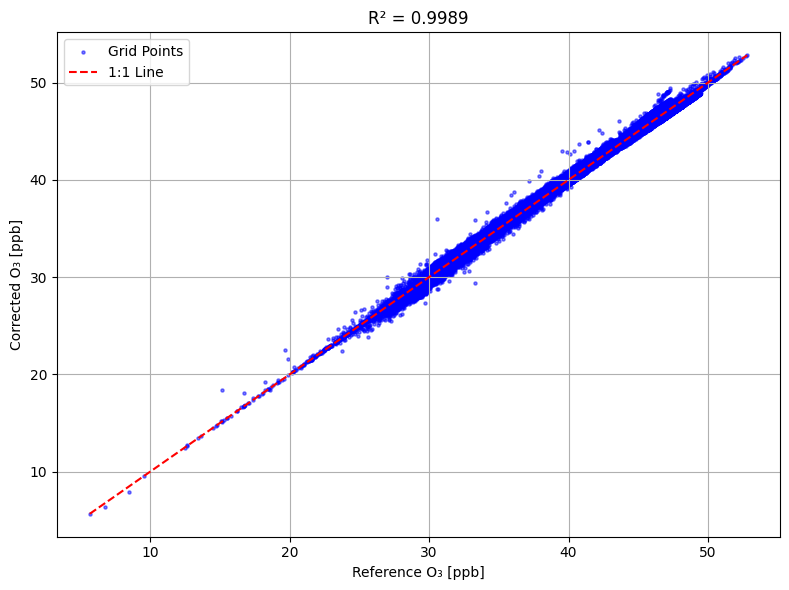

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDFs ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"
file_B = "BaseCase_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract Fields ===
o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

# === Flatten & Mask NaNs ===
mask = ~np.isnan(o3_A) & ~np.isnan(o3_B)
o3_A_flat = o3_A[mask].flatten()
o3_B_flat = o3_B[mask].flatten()

# === Compute R² ===
r2 = r2_score(o3_B_flat, o3_A_flat)
print(f"R² (Corrected vs Reference): {r2:.4f}")

# === Create Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_B_flat, o3_A_flat, s=5, alpha=0.5, color='blue', label='Grid Points')
plt.plot([o3_B_flat.min(), o3_B_flat.max()],
         [o3_B_flat.min(), o3_B_flat.max()],
         color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

# === Plot Formatting ===
plt.xlabel("Reference O₃ [ppb]")
plt.ylabel("Corrected O₃ [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()



R² of average surface O₃ per country (Corrected vs Reference): 0.9994


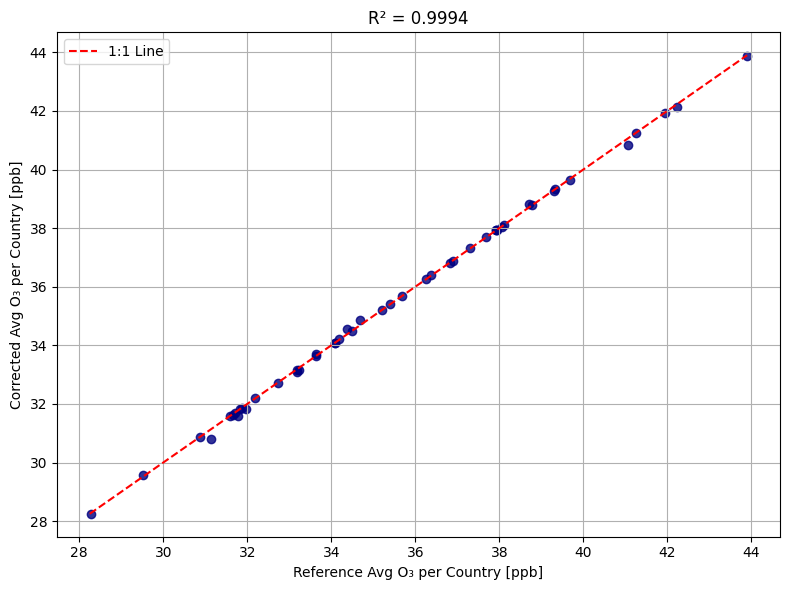

In [14]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDF files ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"
file_B = "BaseCase_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

ds_A.close()
ds_B.close()

# === Load integer country mask and mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Flatten arrays ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_mask = country_mask.flatten()

# === Filter valid data ===
valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B))

# === Create DataFrame for grouping ===
df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid]
})

# === Group by country ID ===
grouped = df.groupby("country_id").mean()

# === Extract average O₃ values per country ===
o3_corr_avg = grouped["o3_corrected"].values
o3_ref_avg = grouped["o3_reference"].values
country_ids = grouped.index.values
iso_codes = [int_to_iso[i] for i in country_ids]

# === Compute R² ===
r2 = r2_score(o3_ref_avg, o3_corr_avg)
print(f"\nR² of average surface O₃ per country (Corrected vs Reference): {r2:.4f}")

# === Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_ref_avg, o3_corr_avg, color='navy', alpha=0.8)

# 1:1 line
min_val = min(o3_ref_avg.min(), o3_corr_avg.min())
max_val = max(o3_ref_avg.max(), o3_corr_avg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and styling
plt.xlabel("Reference Avg O₃ per Country [ppb]")
plt.ylabel("Corrected Avg O₃ per Country [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


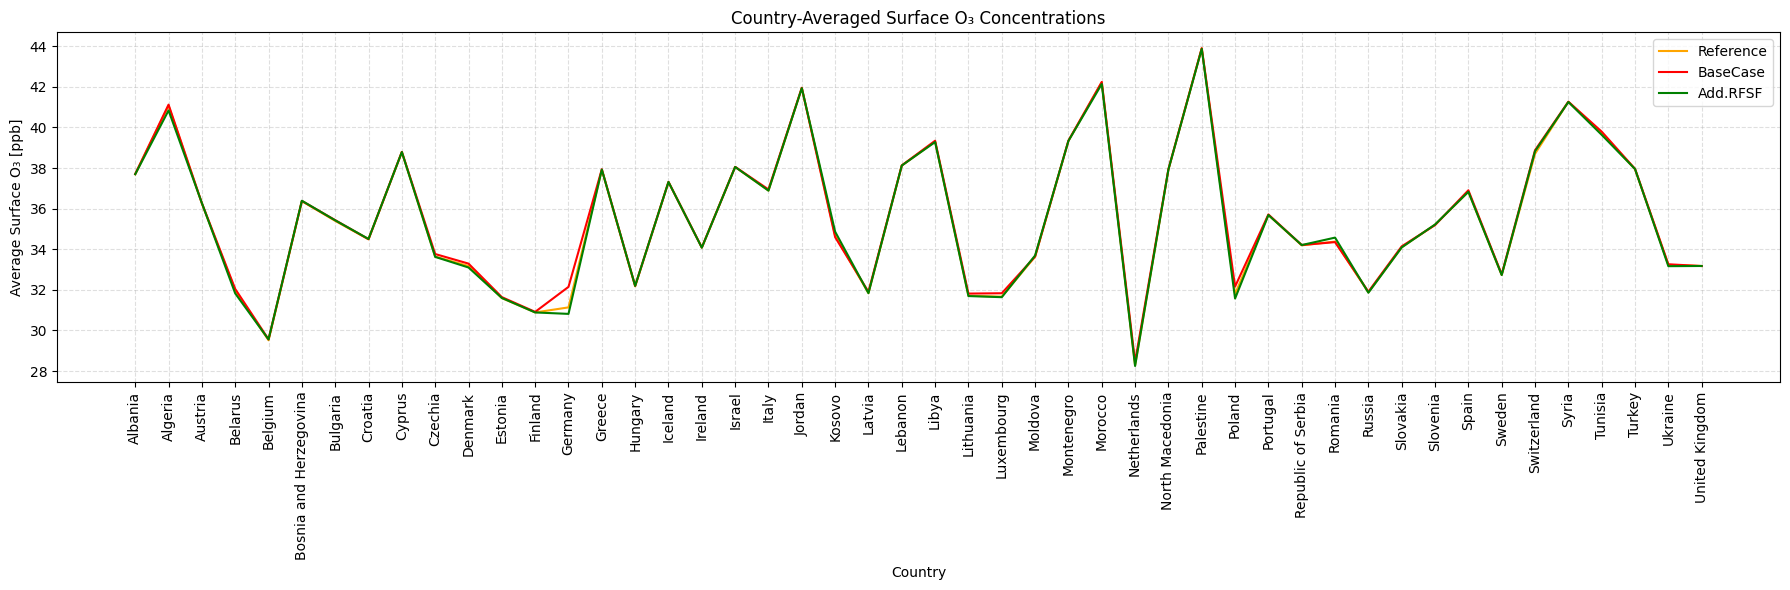

In [15]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load NetCDFs ===


ds_A = xr.open_dataset("BaseCase_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc")  # Corrected
ds_B = xr.open_dataset("BaseCase_REF_O3_YEARLY.nc")                          # Reference
ds_C = xr.open_dataset("BaseCase_PERT_O3_YEARLY.nc")           # BaseCase

o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values
o3_C = ds_C["SURF_ppb_O3"].squeeze().values

ds_A.close()
ds_B.close()
ds_C.close()

# === Load integer country mask and ISO mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Load shapefile to get ISO3 → full country names ===
gdf = gpd.read_file("ne_110m_admin_0_countries.shp")[["ISO_A3", "ADMIN"]]
iso_to_name = dict(zip(gdf["ISO_A3"], gdf["ADMIN"]))

# === Flatten and filter valid values ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_C = o3_C.flatten()
flat_mask = country_mask.flatten()

valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B)) & (~np.isnan(flat_C))

df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid],
    "o3_basecase": flat_C[valid]
})

# === Group by country ID and compute means ===
grouped = df.groupby("country_id").mean()
grouped["ISO3"] = [int_to_iso[i] for i in grouped.index]
grouped["country_name"] = grouped["ISO3"].map(iso_to_name)

# === Sort alphabetically by country name ===
grouped_sorted = grouped.sort_values("country_name")
country_names = grouped_sorted["country_name"].values
ref_vals = grouped_sorted["o3_reference"].values
corr_vals = grouped_sorted["o3_corrected"].values
base_vals = grouped_sorted["o3_basecase"].values

# === Line Plot ===
plt.figure(figsize=(18, 6))
plt.plot(country_names, ref_vals, label="Reference", linestyle='-', color="orange")
plt.plot(country_names, base_vals, label="BaseCase", linestyle='-', color="red")
plt.plot(country_names, corr_vals, label="Add.RFSF", linestyle='-', color="green")

plt.ylabel("Average Surface O₃ [ppb]")
plt.xlabel("Country")
plt.title("Country-Averaged Surface O₃ Concentrations")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


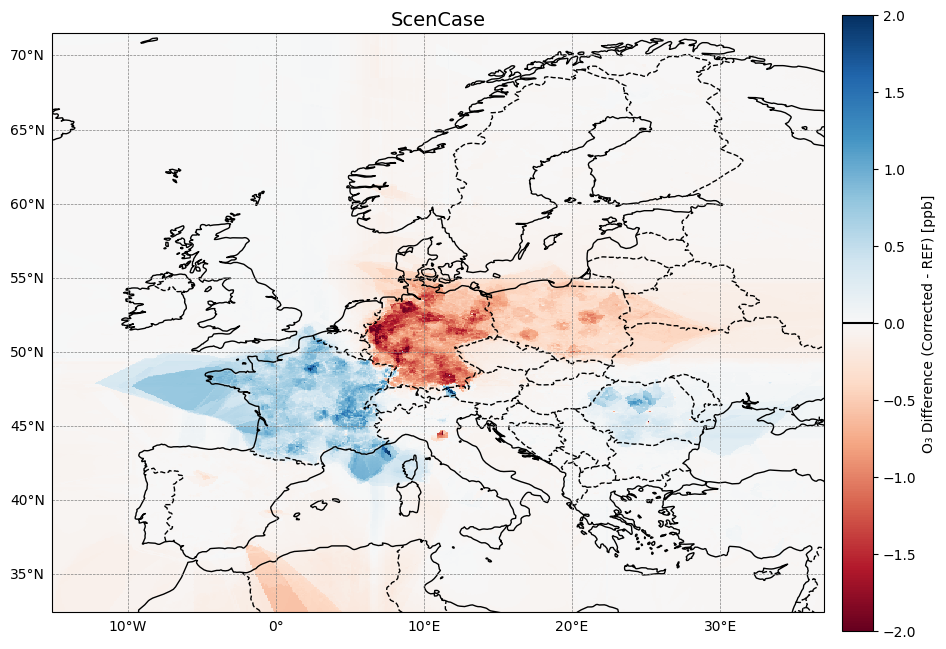

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === File Paths ===
file_A = "Scen_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"  # UoA Corrected
file_B = "SCEN_REF_O3_YEARLY.nc"  # Reference

# === Open NetCDFs ===
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract O₃ Fields ===
# Both will now have shape (lat, lon)
o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values

# === Compute Difference (Corrected - Reference) ===
o3_diff = o3_A - o3_B

# === Extract Coordinates (1D) and Meshgrid (2D) ===
lon = ds_A["lon"].values
lat = ds_A["lat"].values
lon2d, lat2d = np.meshgrid(lon, lat)  # Shape matches (lat, lon)

# === Define Colorbar Limits ===
vmin, vmax = -2, 2  # Adjust if needed

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon2d, lat2d, o3_diff, transform=ccrs.PlateCarree(),
                   cmap="RdBu", vmin=vmin, vmax=vmax, shading='nearest')

# === Colorbar ===
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("O₃ Difference (Corrected - REF) [ppb]")
cbar.ax.hlines(0, *cbar.ax.get_xlim(), colors='black', linewidth=1.5)

# === Map Features ===
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# === Gridlines ===
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# === Title and Labels ===
ax.set_title("ScenCase", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()


R² (Corrected vs Reference): 0.9975


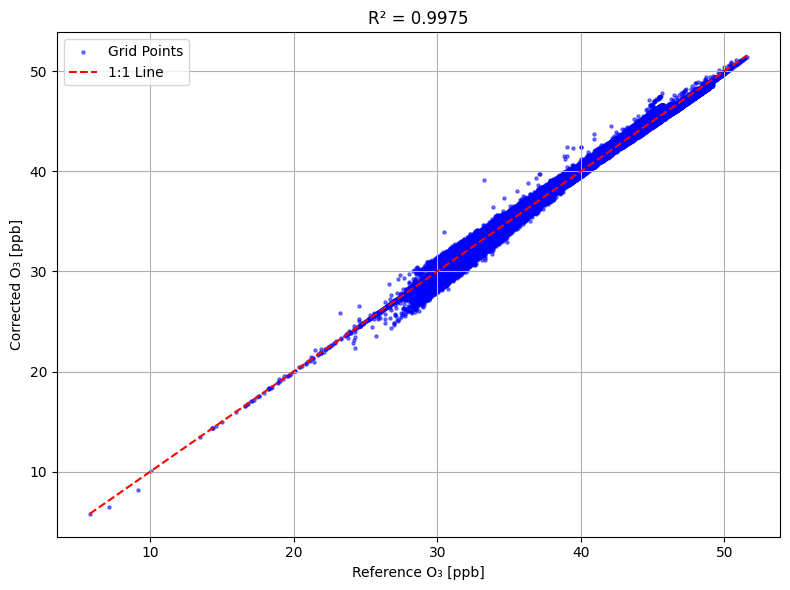

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDFs ===
file_A = "Scen_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"  # UoA Corrected
file_B = "SCEN_REF_O3_YEARLY.nc"  # Reference
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract Fields ===
o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

# === Flatten & Mask NaNs ===
mask = ~np.isnan(o3_A) & ~np.isnan(o3_B)
o3_A_flat = o3_A[mask].flatten()
o3_B_flat = o3_B[mask].flatten()

# === Compute R² ===
r2 = r2_score(o3_B_flat, o3_A_flat)
print(f"R² (Corrected vs Reference): {r2:.4f}")

# === Create Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_B_flat, o3_A_flat, s=5, alpha=0.5, color='blue', label='Grid Points')
plt.plot([o3_B_flat.min(), o3_B_flat.max()],
         [o3_B_flat.min(), o3_B_flat.max()],
         color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

# === Plot Formatting ===
plt.xlabel("Reference O₃ [ppb]")
plt.ylabel("Corrected O₃ [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()



R² of average surface O₃ per country (Corrected vs Reference): 0.9972


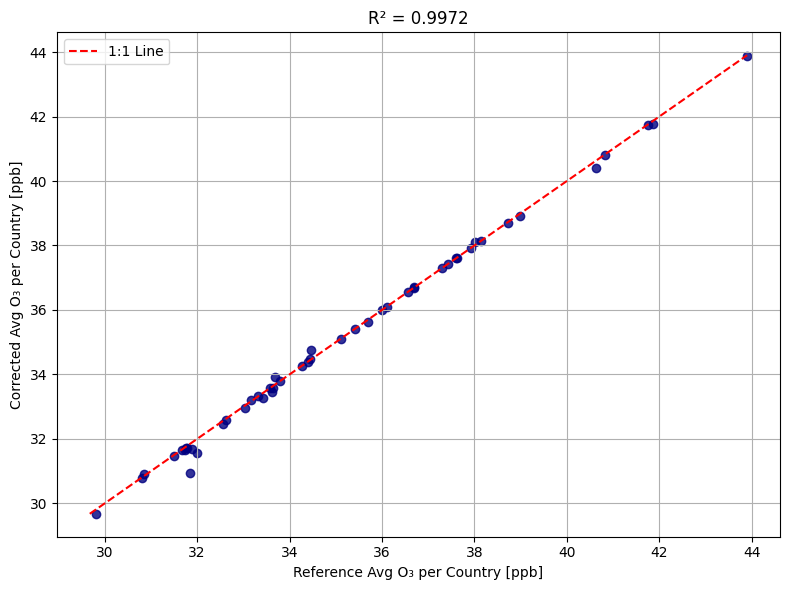

In [18]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDF files ===
file_A = "Scen_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc"  # UoA Corrected
file_B = "SCEN_REF_O3_YEARLY.nc"  # Reference
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

ds_A.close()
ds_B.close()

# === Load integer country mask and mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Flatten arrays ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_mask = country_mask.flatten()

# === Filter valid data ===
valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B))

# === Create DataFrame for grouping ===
df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid]
})

# === Group by country ID ===
grouped = df.groupby("country_id").mean()

# === Extract average O₃ values per country ===
o3_corr_avg = grouped["o3_corrected"].values
o3_ref_avg = grouped["o3_reference"].values
country_ids = grouped.index.values
iso_codes = [int_to_iso[i] for i in country_ids]

# === Compute R² ===
r2 = r2_score(o3_ref_avg, o3_corr_avg)
print(f"\nR² of average surface O₃ per country (Corrected vs Reference): {r2:.4f}")

# === Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_ref_avg, o3_corr_avg, color='navy', alpha=0.8)

# 1:1 line
min_val = min(o3_ref_avg.min(), o3_corr_avg.min())
max_val = max(o3_ref_avg.max(), o3_corr_avg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and styling
plt.xlabel("Reference Avg O₃ per Country [ppb]")
plt.ylabel("Corrected Avg O₃ per Country [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


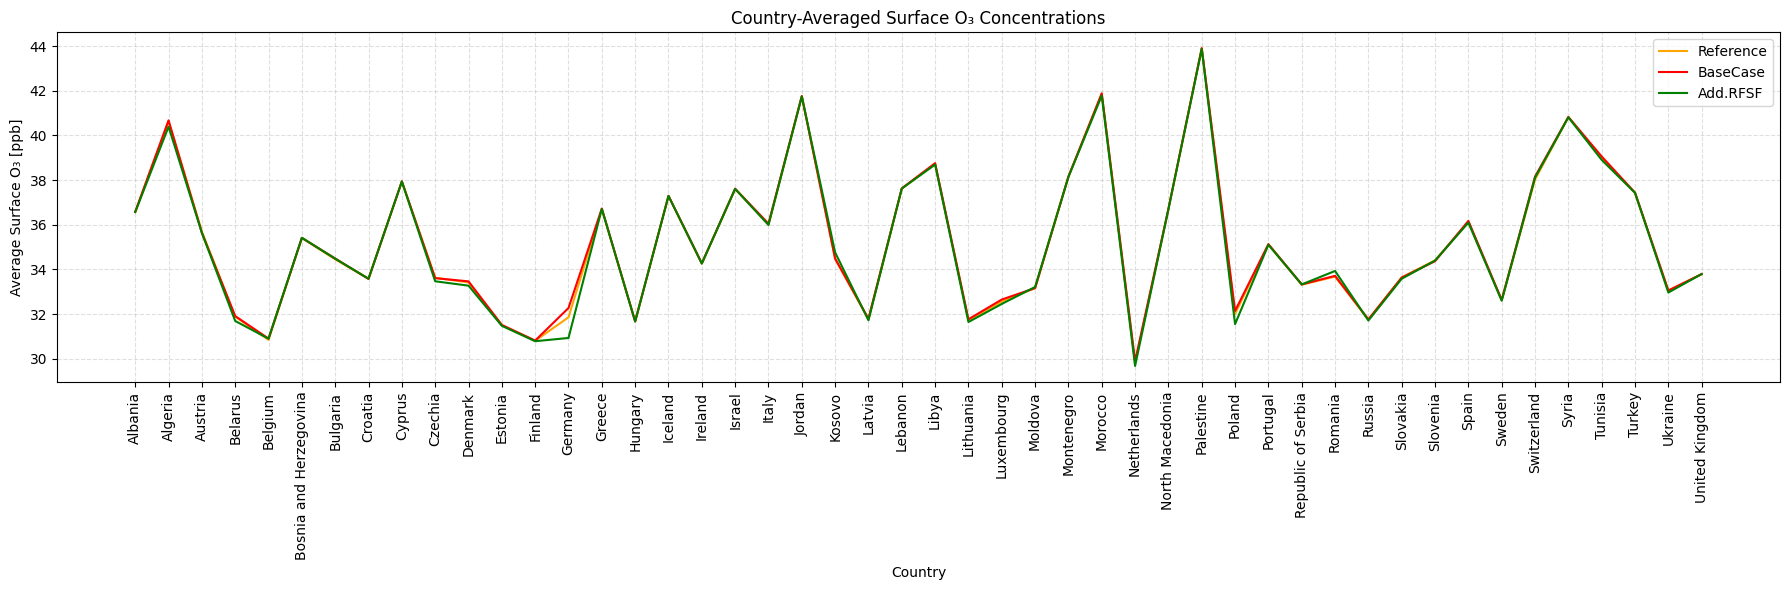

In [19]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load NetCDFs ===


ds_A = xr.open_dataset("Scen_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc")  # Corrected
ds_B = xr.open_dataset("SCEN_REF_O3_YEARLY.nc")                          # Reference
ds_C = xr.open_dataset("SCEN_PERT_O3_YEARLY.nc")           # BaseCase

o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values
o3_C = ds_C["SURF_ppb_O3"].squeeze().values

ds_A.close()
ds_B.close()
ds_C.close()

# === Load integer country mask and ISO mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Load shapefile to get ISO3 → full country names ===
gdf = gpd.read_file("ne_110m_admin_0_countries.shp")[["ISO_A3", "ADMIN"]]
iso_to_name = dict(zip(gdf["ISO_A3"], gdf["ADMIN"]))

# === Flatten and filter valid values ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_C = o3_C.flatten()
flat_mask = country_mask.flatten()

valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B)) & (~np.isnan(flat_C))

df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid],
    "o3_basecase": flat_C[valid]
})

# === Group by country ID and compute means ===
grouped = df.groupby("country_id").mean()
grouped["ISO3"] = [int_to_iso[i] for i in grouped.index]
grouped["country_name"] = grouped["ISO3"].map(iso_to_name)

# === Sort alphabetically by country name ===
grouped_sorted = grouped.sort_values("country_name")
country_names = grouped_sorted["country_name"].values
ref_vals = grouped_sorted["o3_reference"].values
corr_vals = grouped_sorted["o3_corrected"].values
base_vals = grouped_sorted["o3_basecase"].values

# === Line Plot ===
plt.figure(figsize=(18, 6))
plt.plot(country_names, ref_vals, label="Reference", linestyle='-', color="orange")
plt.plot(country_names, base_vals, label="BaseCase", linestyle='-', color="red")
plt.plot(country_names, corr_vals, label="Add.RFSF", linestyle='-', color="green")

plt.ylabel("Average Surface O₃ [ppb]")
plt.xlabel("Country")
plt.title("Country-Averaged Surface O₃ Concentrations")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# Multiplicative

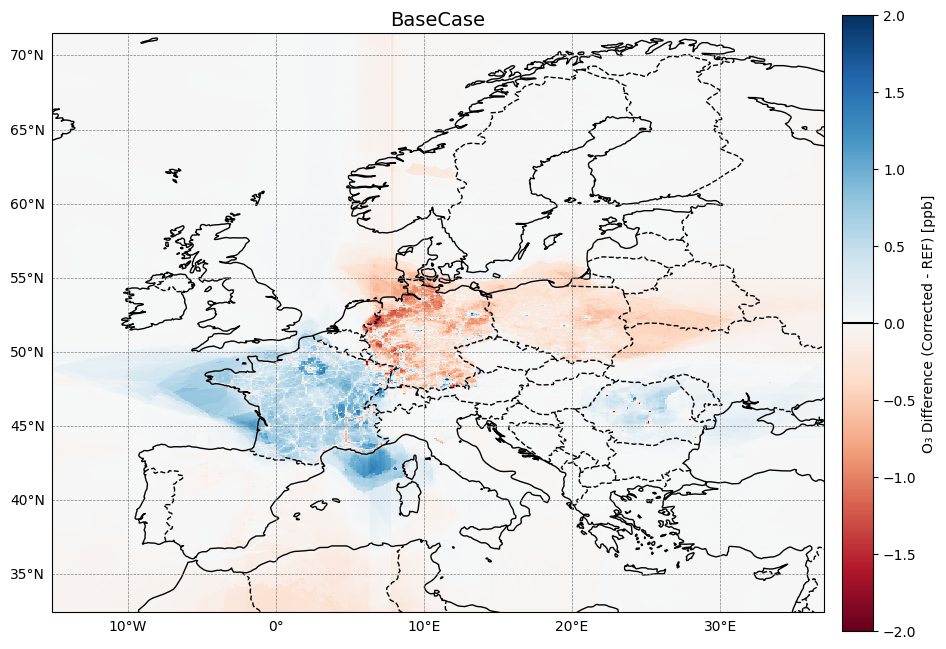

In [20]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === File Paths ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "BaseCase_REF_O3_YEARLY.nc"

# === Open NetCDFs ===
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract O₃ Fields ===
# Both will now have shape (lat, lon)
o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values

# === Compute Difference (Corrected - Reference) ===
o3_diff = o3_A - o3_B

# === Extract Coordinates (1D) and Meshgrid (2D) ===
lon = ds_A["lon"].values
lat = ds_A["lat"].values
lon2d, lat2d = np.meshgrid(lon, lat)  # Shape matches (lat, lon)

# === Define Colorbar Limits ===
vmin, vmax = -2, 2  # Adjust if needed

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon2d, lat2d, o3_diff, transform=ccrs.PlateCarree(),
                   cmap="RdBu", vmin=vmin, vmax=vmax, shading='nearest')

# === Colorbar ===
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("O₃ Difference (Corrected - REF) [ppb]")
cbar.ax.hlines(0, *cbar.ax.get_xlim(), colors='black', linewidth=1.5)

# === Map Features ===
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# === Gridlines ===
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# === Title and Labels ===
ax.set_title("BaseCase", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()


R² (Corrected vs Reference): 0.9987


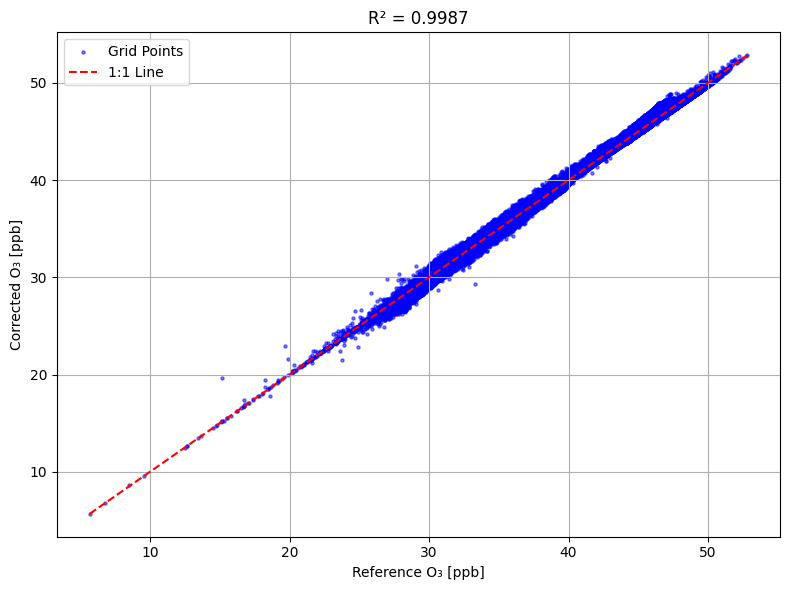

In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDFs ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "BaseCase_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract Fields ===
o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

# === Flatten & Mask NaNs ===
mask = ~np.isnan(o3_A) & ~np.isnan(o3_B)
o3_A_flat = o3_A[mask].flatten()
o3_B_flat = o3_B[mask].flatten()

# === Compute R² ===
r2 = r2_score(o3_B_flat, o3_A_flat)
print(f"R² (Corrected vs Reference): {r2:.4f}")

# === Create Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_B_flat, o3_A_flat, s=5, alpha=0.5, color='blue', label='Grid Points')
plt.plot([o3_B_flat.min(), o3_B_flat.max()],
         [o3_B_flat.min(), o3_B_flat.max()],
         color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

# === Plot Formatting ===
plt.xlabel("Reference O₃ [ppb]")
plt.ylabel("Corrected O₃ [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()



R² of average surface O₃ per country (Corrected vs Reference): 0.9992


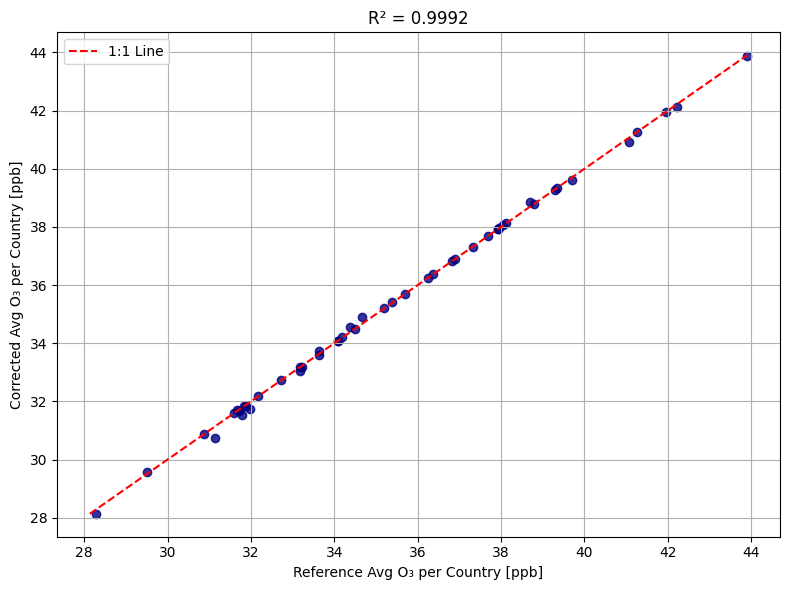

In [22]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDF files ===
file_A = "BaseCase_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "BaseCase_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

ds_A.close()
ds_B.close()

# === Load integer country mask and mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Flatten arrays ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_mask = country_mask.flatten()

# === Filter valid data ===
valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B))

# === Create DataFrame for grouping ===
df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid]
})

# === Group by country ID ===
grouped = df.groupby("country_id").mean()

# === Extract average O₃ values per country ===
o3_corr_avg = grouped["o3_corrected"].values
o3_ref_avg = grouped["o3_reference"].values
country_ids = grouped.index.values
iso_codes = [int_to_iso[i] for i in country_ids]

# === Compute R² ===
r2 = r2_score(o3_ref_avg, o3_corr_avg)
print(f"\nR² of average surface O₃ per country (Corrected vs Reference): {r2:.4f}")

# === Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_ref_avg, o3_corr_avg, color='navy', alpha=0.8)

# 1:1 line
min_val = min(o3_ref_avg.min(), o3_corr_avg.min())
max_val = max(o3_ref_avg.max(), o3_corr_avg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and styling
plt.xlabel("Reference Avg O₃ per Country [ppb]")
plt.ylabel("Corrected Avg O₃ per Country [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


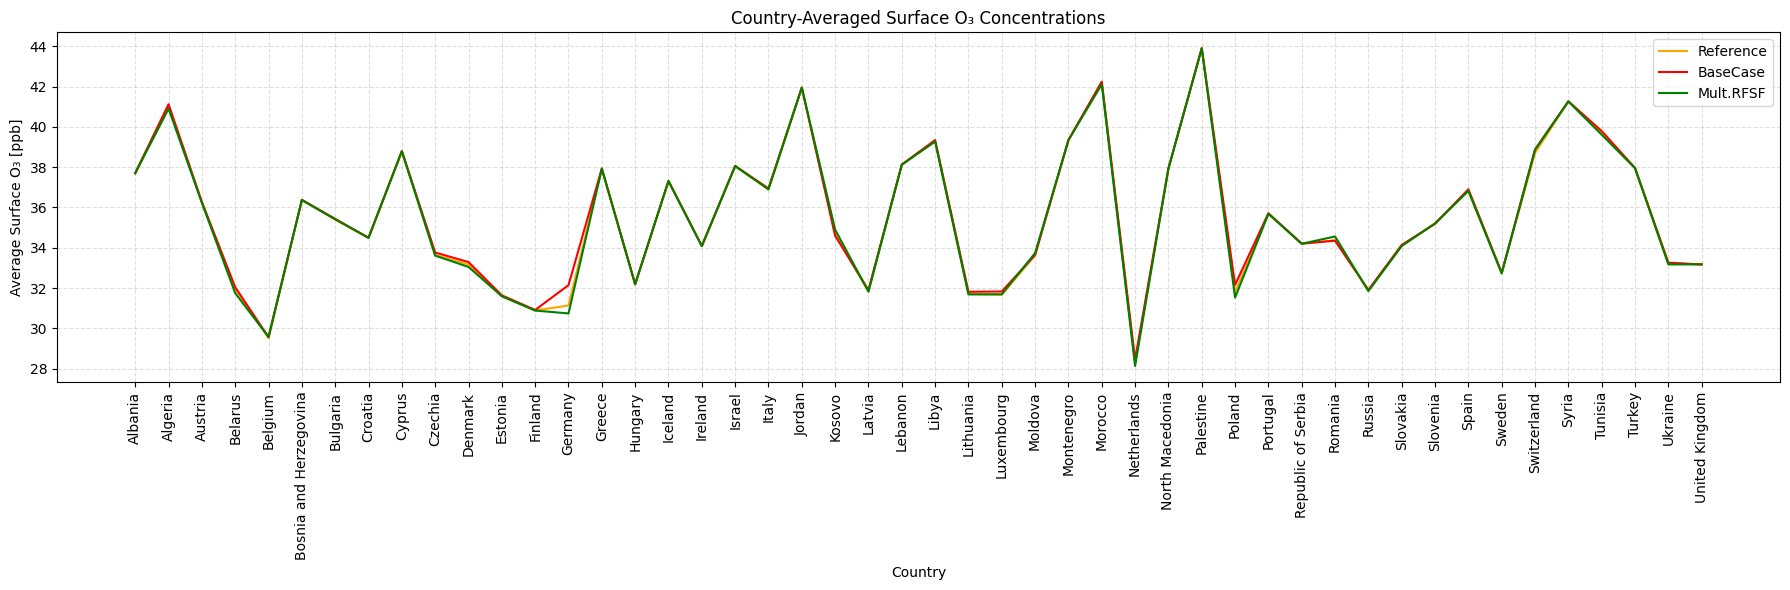

In [23]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load NetCDFs ===


ds_A = xr.open_dataset("BaseCase_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc")  # Corrected
ds_B = xr.open_dataset("BaseCase_REF_O3_YEARLY.nc")                          # Reference
ds_C = xr.open_dataset("BaseCase_PERT_O3_YEARLY.nc")           # BaseCase

o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values
o3_C = ds_C["SURF_ppb_O3"].squeeze().values

ds_A.close()
ds_B.close()
ds_C.close()

# === Load integer country mask and ISO mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Load shapefile to get ISO3 → full country names ===
gdf = gpd.read_file("ne_110m_admin_0_countries.shp")[["ISO_A3", "ADMIN"]]
iso_to_name = dict(zip(gdf["ISO_A3"], gdf["ADMIN"]))

# === Flatten and filter valid values ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_C = o3_C.flatten()
flat_mask = country_mask.flatten()

valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B)) & (~np.isnan(flat_C))

df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid],
    "o3_basecase": flat_C[valid]
})

# === Group by country ID and compute means ===
grouped = df.groupby("country_id").mean()
grouped["ISO3"] = [int_to_iso[i] for i in grouped.index]
grouped["country_name"] = grouped["ISO3"].map(iso_to_name)

# === Sort alphabetically by country name ===
grouped_sorted = grouped.sort_values("country_name")
country_names = grouped_sorted["country_name"].values
ref_vals = grouped_sorted["o3_reference"].values
corr_vals = grouped_sorted["o3_corrected"].values
base_vals = grouped_sorted["o3_basecase"].values

# === Line Plot ===
plt.figure(figsize=(18, 6))
plt.plot(country_names, ref_vals, label="Reference", linestyle='-', color="orange")
plt.plot(country_names, base_vals, label="BaseCase", linestyle='-', color="red")
plt.plot(country_names, corr_vals, label="Mult.RFSF", linestyle='-', color="green")

plt.ylabel("Average Surface O₃ [ppb]")
plt.xlabel("Country")
plt.title("Country-Averaged Surface O₃ Concentrations")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


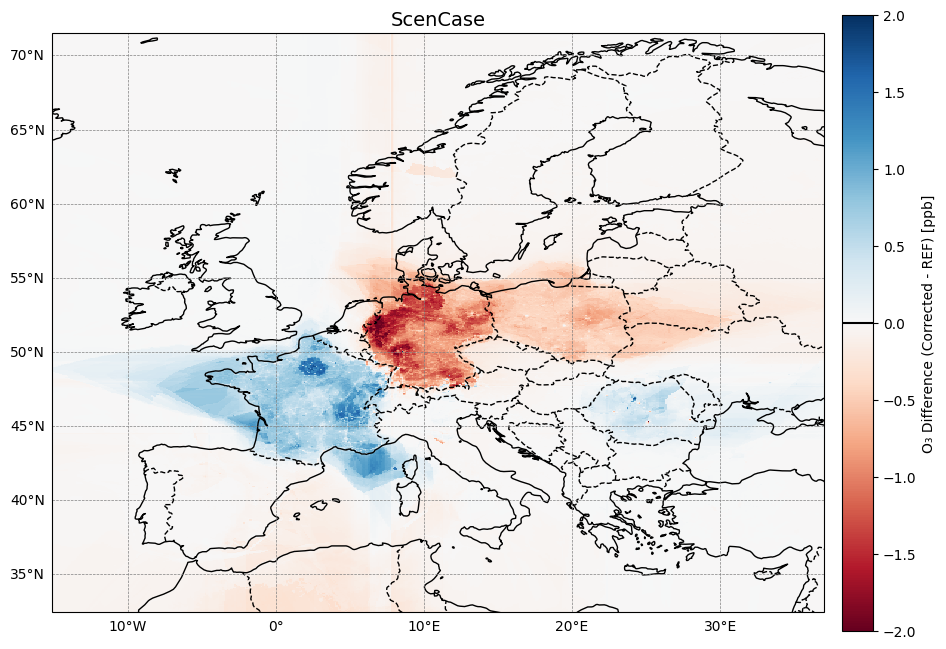

In [24]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === File Paths ===
file_A = "Scen_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "SCEN_REF_O3_YEARLY.nc"

# === Open NetCDFs ===
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract O₃ Fields ===
# Both will now have shape (lat, lon)
o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values

# === Compute Difference (Corrected - Reference) ===
o3_diff = o3_A - o3_B

# === Extract Coordinates (1D) and Meshgrid (2D) ===
lon = ds_A["lon"].values
lat = ds_A["lat"].values
lon2d, lat2d = np.meshgrid(lon, lat)  # Shape matches (lat, lon)

# === Define Colorbar Limits ===
vmin, vmax = -2, 2  # Adjust if needed

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(lon2d, lat2d, o3_diff, transform=ccrs.PlateCarree(),
                   cmap="RdBu", vmin=vmin, vmax=vmax, shading='nearest')

# === Colorbar ===
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("O₃ Difference (Corrected - REF) [ppb]")
cbar.ax.hlines(0, *cbar.ax.get_xlim(), colors='black', linewidth=1.5)

# === Map Features ===
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# === Gridlines ===
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# === Title and Labels ===
ax.set_title("ScenCase", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()


R² (Corrected vs Reference): 0.9971


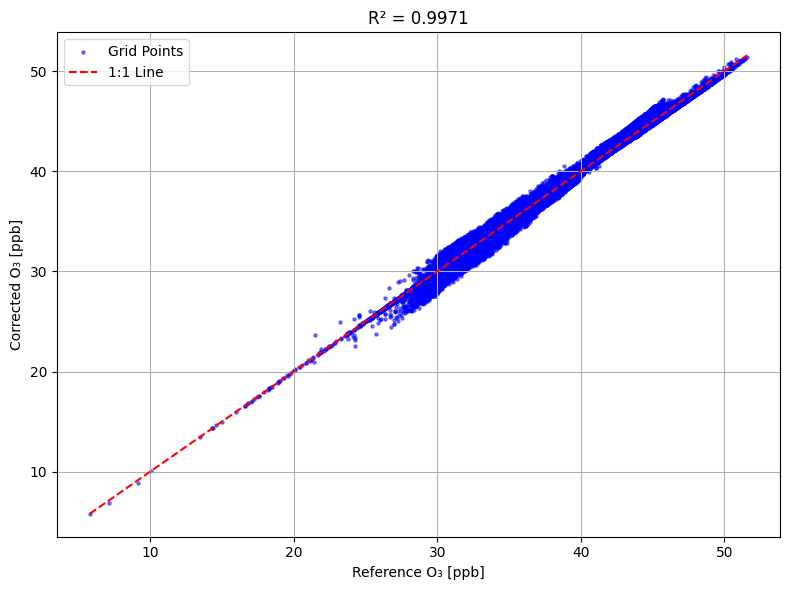

In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDFs ===
file_A = "Scen_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "SCEN_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

# === Extract Fields ===
o3_A = ds_A["SURF_ppb_O3"].squeeze().values # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

# === Flatten & Mask NaNs ===
mask = ~np.isnan(o3_A) & ~np.isnan(o3_B)
o3_A_flat = o3_A[mask].flatten()
o3_B_flat = o3_B[mask].flatten()

# === Compute R² ===
r2 = r2_score(o3_B_flat, o3_A_flat)
print(f"R² (Corrected vs Reference): {r2:.4f}")

# === Create Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_B_flat, o3_A_flat, s=5, alpha=0.5, color='blue', label='Grid Points')
plt.plot([o3_B_flat.min(), o3_B_flat.max()],
         [o3_B_flat.min(), o3_B_flat.max()],
         color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

# === Plot Formatting ===
plt.xlabel("Reference O₃ [ppb]")
plt.ylabel("Corrected O₃ [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# === Show Plot ===
plt.show()

# === Close Datasets ===
ds_A.close()
ds_B.close()



R² of average surface O₃ per country (Corrected vs Reference): 0.9966


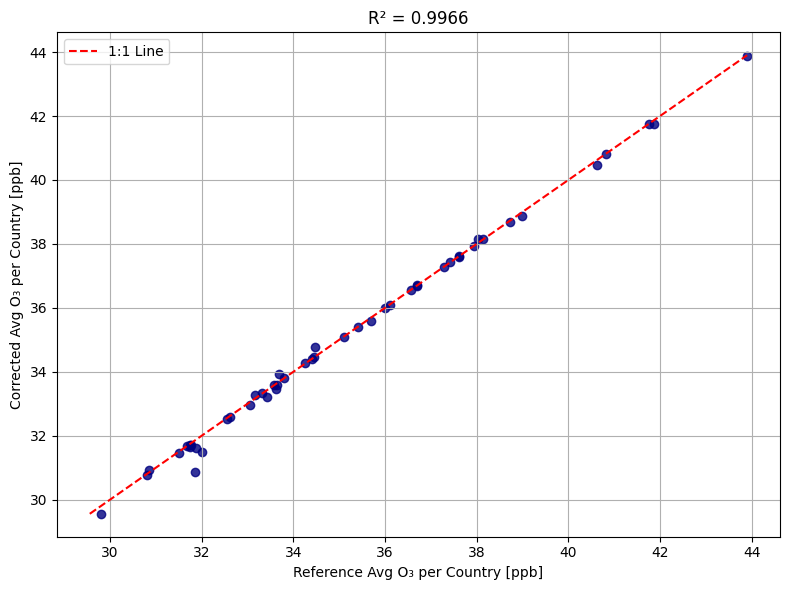

In [26]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === Load NetCDF files ===
file_A = "Scen_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc"
file_B = "SCEN_REF_O3_YEARLY.nc"
ds_A = xr.open_dataset(file_A)
ds_B = xr.open_dataset(file_B)

o3_A = ds_A["SURF_ppb_O3"].squeeze().values  # Corrected
o3_B = ds_B["SURF_ppb_O3"].squeeze().values  # Reference

ds_A.close()
ds_B.close()

# === Load integer country mask and mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Flatten arrays ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_mask = country_mask.flatten()

# === Filter valid data ===
valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B))

# === Create DataFrame for grouping ===
df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid]
})

# === Group by country ID ===
grouped = df.groupby("country_id").mean()

# === Extract average O₃ values per country ===
o3_corr_avg = grouped["o3_corrected"].values
o3_ref_avg = grouped["o3_reference"].values
country_ids = grouped.index.values
iso_codes = [int_to_iso[i] for i in country_ids]

# === Compute R² ===
r2 = r2_score(o3_ref_avg, o3_corr_avg)
print(f"\nR² of average surface O₃ per country (Corrected vs Reference): {r2:.4f}")

# === Scatterplot ===
plt.figure(figsize=(8, 6))
plt.scatter(o3_ref_avg, o3_corr_avg, color='navy', alpha=0.8)

# 1:1 line
min_val = min(o3_ref_avg.min(), o3_corr_avg.min())
max_val = max(o3_ref_avg.max(), o3_corr_avg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line")

# Labels and styling
plt.xlabel("Reference Avg O₃ per Country [ppb]")
plt.ylabel("Corrected Avg O₃ per Country [ppb]")
plt.title(f"R² = {r2:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


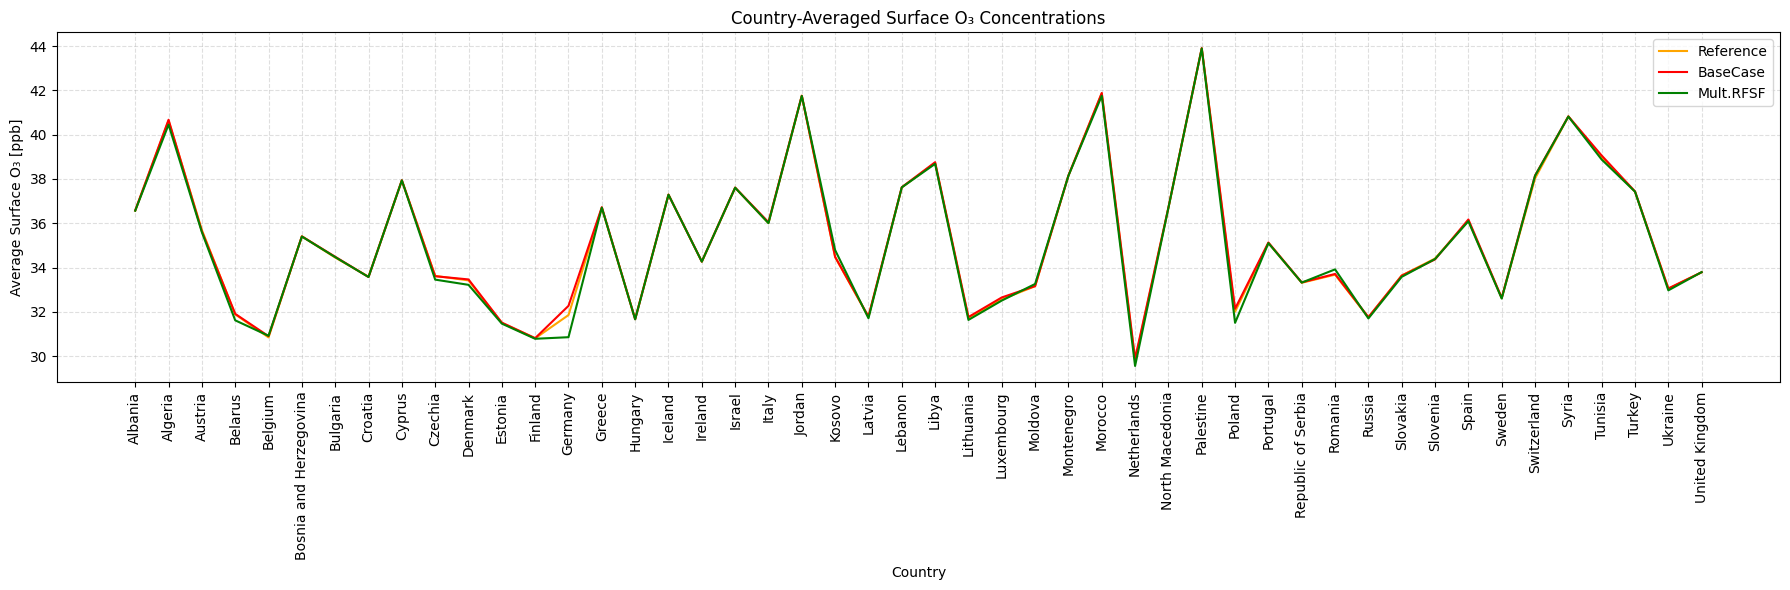

In [27]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load NetCDFs ===
ds_A = xr.open_dataset("Scen_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc")  # Corrected
ds_B = xr.open_dataset("SCEN_REF_O3_YEARLY.nc")                          # Reference
ds_C = xr.open_dataset("SCEN_PERT_O3_YEARLY.nc")           # BaseCase

o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values
o3_C = ds_C["SURF_ppb_O3"].squeeze().values

ds_A.close()
ds_B.close()
ds_C.close()

# === Load integer country mask and ISO mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Load shapefile to get ISO3 → full country names ===
gdf = gpd.read_file("ne_110m_admin_0_countries.shp")[["ISO_A3", "ADMIN"]]
iso_to_name = dict(zip(gdf["ISO_A3"], gdf["ADMIN"]))

# === Flatten and filter valid values ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_C = o3_C.flatten()
flat_mask = country_mask.flatten()

valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B)) & (~np.isnan(flat_C))

df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid],
    "o3_basecase": flat_C[valid]
})

# === Group by country ID and compute means ===
grouped = df.groupby("country_id").mean()
grouped["ISO3"] = [int_to_iso[i] for i in grouped.index]
grouped["country_name"] = grouped["ISO3"].map(iso_to_name)

# === Sort alphabetically by country name ===
grouped_sorted = grouped.sort_values("country_name")
country_names = grouped_sorted["country_name"].values
ref_vals = grouped_sorted["o3_reference"].values
corr_vals = grouped_sorted["o3_corrected"].values
base_vals = grouped_sorted["o3_basecase"].values

# === Line Plot ===
plt.figure(figsize=(18, 6))
plt.plot(country_names, ref_vals, label="Reference", linestyle='-', color="orange")
plt.plot(country_names, base_vals, label="BaseCase", linestyle='-', color="red")
plt.plot(country_names, corr_vals, label="Mult.RFSF", linestyle='-', color="green")

plt.ylabel("Average Surface O₃ [ppb]")
plt.xlabel("Country")
plt.title("Country-Averaged Surface O₃ Concentrations")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


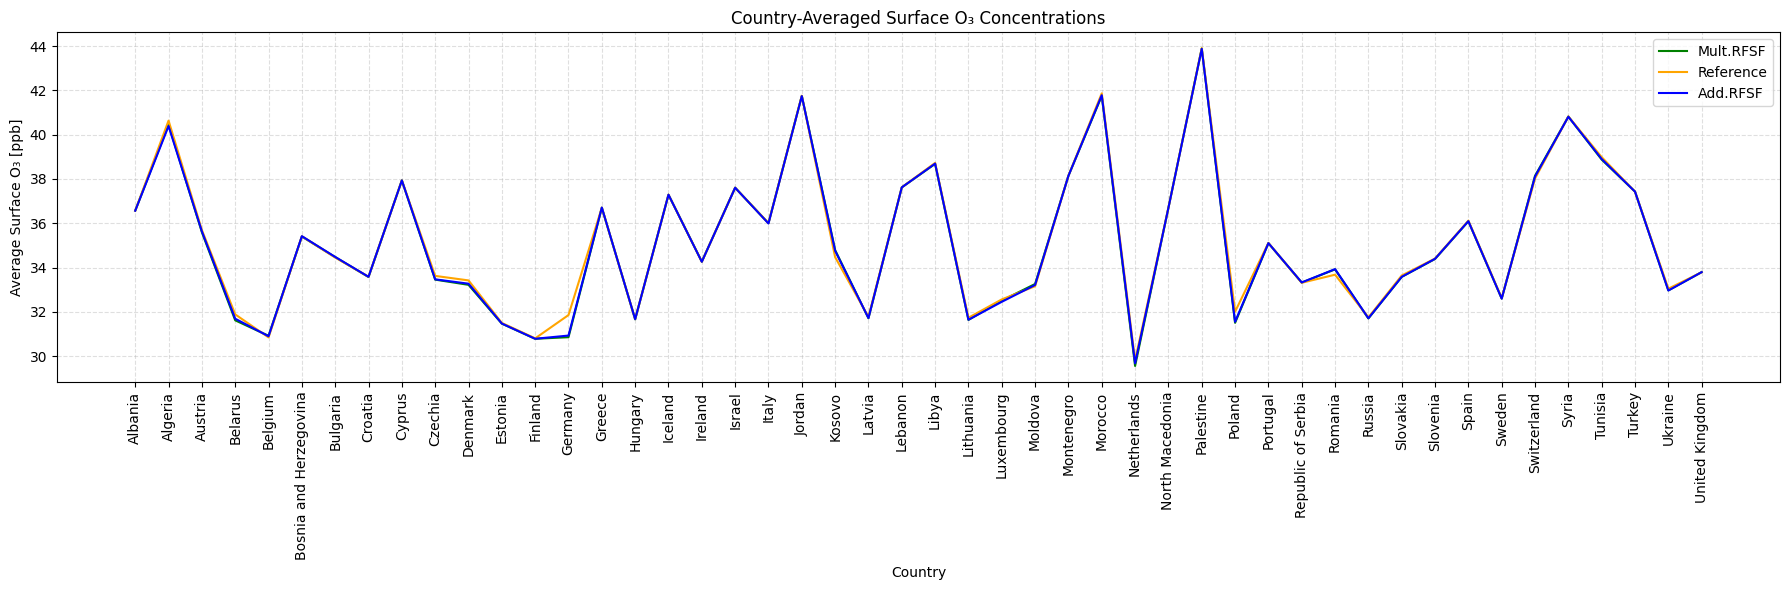

In [29]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load NetCDFs ===
ds_A = xr.open_dataset("Scen_UoA_O3_CSA.Cell.Mult.RFSF_CORR_YEARLY.nc")  # Corrected
ds_B = xr.open_dataset("SCEN_REF_O3_YEARLY.nc")                          # Reference
ds_C = xr.open_dataset("Scen_UoA_O3_CSA.Cell.Add.RFSF_CORR_YEARLY.nc")           # BaseCase

o3_A = ds_A["SURF_ppb_O3"].squeeze().values
o3_B = ds_B["SURF_ppb_O3"].squeeze().values
o3_C = ds_C["SURF_ppb_O3"].squeeze().values

ds_A.close()
ds_B.close()
ds_C.close()

# === Load integer country mask and ISO mapping ===
country_mask = np.load("country_mask_int.npy")
int_to_iso = np.load("int_to_iso.npy", allow_pickle=True).item()

# === Load shapefile to get ISO3 → full country names ===
gdf = gpd.read_file("ne_110m_admin_0_countries.shp")[["ISO_A3", "ADMIN"]]
iso_to_name = dict(zip(gdf["ISO_A3"], gdf["ADMIN"]))

# === Flatten and filter valid values ===
flat_A = o3_A.flatten()
flat_B = o3_B.flatten()
flat_C = o3_C.flatten()
flat_mask = country_mask.flatten()

valid = (flat_mask != -1) & (~np.isnan(flat_A)) & (~np.isnan(flat_B)) & (~np.isnan(flat_C))

df = pd.DataFrame({
    "country_id": flat_mask[valid],
    "o3_corrected": flat_A[valid],
    "o3_reference": flat_B[valid],
    "o3_basecase": flat_C[valid]
})

# === Group by country ID and compute means ===
grouped = df.groupby("country_id").mean()
grouped["ISO3"] = [int_to_iso[i] for i in grouped.index]
grouped["country_name"] = grouped["ISO3"].map(iso_to_name)

# === Sort alphabetically by country name ===
grouped_sorted = grouped.sort_values("country_name")
country_names = grouped_sorted["country_name"].values
ref_vals = grouped_sorted["o3_reference"].values
corr_vals = grouped_sorted["o3_corrected"].values
base_vals = grouped_sorted["o3_basecase"].values

# === Line Plot ===
plt.figure(figsize=(18, 6))
plt.plot(country_names, corr_vals, label="Mult.RFSF", linestyle='-', color="green")
plt.plot(country_names, ref_vals, label="Reference", linestyle='-', color="orange")
plt.plot(country_names, base_vals, label="Αdd.RFSF", linestyle='-', color="blue")

plt.ylabel("Average Surface O₃ [ppb]")
plt.xlabel("Country")
plt.title("Country-Averaged Surface O₃ Concentrations")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
